In [1]:
include("PermBasis.jl")
include("PlotSetup.jl")
include("MonteCarloMF.jl")
using PyPlot
using DifferentialEquations
using JLD2

legend_kwargs = (
    fontsize=12,
    framealpha=0.9,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=2.0
)

(fontsize = 12, framealpha = 0.9, borderpad = 0.3, labelspacing = 0.3, handlelength = 2.0)

In [55]:
function generate_fig2b_gamma_data(; N = 10000, time_factor = 200, N_traj = 400, n_bg = 10, g_xi = 0.5, gbar_gamma = 0.2)
    Γ = 1.0
    ξ = g_xi * N * Γ
    γ = gbar_gamma * N * Γ / log(N)

    params = Dict(
        "global_decay" => Γ,
        "global_pump" => 0.0,
        "local_pump" => 0.0,
        "local_dephasing" => ξ,
        "local_decay" => γ,
    )

    tmax = time_factor * log(N) / N

    bg_trajectories = Vector{Tuple{Vector{Float64}, Vector{Float64}}}(undef, n_bg)
    for j in 1:n_bg
        times, sol = simulate_ensemble(
            N,
            params["global_decay"],
            params["local_dephasing"],
            params["local_decay"],
            tmax,
            (S, M, N, Γ, ξ) -> [S, M],
            1
        )
        bg_trajectories[j] = (
            collect(element(sol, 1) ./ N),
            collect(element(sol, 2) ./ N)
        )
    end

    times_mc, sol_mc = simulate_ensemble(
        N,
        params["global_decay"],
        params["local_dephasing"],
        params["local_decay"],
        tmax,
        (S, M, N, Γ, ξ) -> [S, M],
        N_traj
    )
    S_mc = collect(element(sol_mc, 1) ./ N)
    M_mc = collect(element(sol_mc, 2) ./ N)

    p = [params["global_decay"], params["local_dephasing"], N, params["local_decay"]]
    u0 = [1 / N, 1 / 2]
    prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
    mfsol = solve(prob, AutoTsit5(Rosenbrock23()), reltol = 1e-8, abstol = 1e-8)

    M_mf = [u[2] for u in mfsol.u]
    I_mf = [u[1] for u in mfsol.u]
    S_mf = sqrt.(I_mf .+ M_mf .^ 2)

    Sgrid = collect(range(0.0, 0.5, length = 400))
    upper_boundary = copy(Sgrid)
    lower_boundary = -Sgrid
    vertical_boundary_x = [0.5, 0.5]
    vertical_boundary_y = [-0.5, 0.5]

    return (
        N = N,
        time_factor = time_factor,
        N_traj = N_traj,
        n_bg = n_bg,
        g_xi = g_xi,
        gbar_gamma = gbar_gamma,
        tmax = tmax,
        times_mc = collect(times_mc),
        S_mc = S_mc,
        M_mc = M_mc,
        times_mf = collect(mfsol.t),
        S_mf = S_mf,
        M_mf = M_mf,
        bg_trajectories = bg_trajectories,
        Sgrid = Sgrid,
        upper_boundary = upper_boundary,
        lower_boundary = lower_boundary,
        vertical_boundary_x = vertical_boundary_x,
        vertical_boundary_y = vertical_boundary_y,
    )
end

function plot_fig2b_gamma!(ax, data)
    for (S_bg, M_bg) in data["bg_trajectories"]
        ax.plot(S_bg, M_bg, color="k", alpha=0.15, linestyle="solid", linewidth=1.0)
    end

    ax.plot(data["S_mc"], data["M_mc"], color="blue", linestyle="solid", linewidth=2.0, label="MC average")
    ax.plot(data["S_mf"], data["M_mf"], color="red", linestyle="solid", linewidth=2.0, label="Mean field")

    ax.plot(data["Sgrid"], data["upper_boundary"], "k--", linewidth=1.5)
    ax.plot(data["Sgrid"], data["lower_boundary"], "k--", linewidth=1.5)
    ax.plot(data["vertical_boundary_x"], data["vertical_boundary_y"], "k--", linewidth=1.5)

    ax.set_xlabel(L"S/N")
    ax.set_ylabel(L"M/N")
    ax.legend(loc="lower left"; legend_kwargs...)

    return ax
end

function generate_compare_mc_mf_intensity_gamma_data(; N = 30000, t_fac = 20, N_traj = 1000, g_xi = 0.5, gbars_gamma = range(0.0, 1.1, 10))
    Γ = 1.0
    ξ = g_xi * N * Γ
    tmax = t_fac * log(N) / N

    curves = Vector{NamedTuple}(undef, length(gbars_gamma))

    for (i, gbar_gamma) in enumerate(gbars_gamma)
        γ = gbar_gamma * N * Γ / log(N)

        ts_mc, intens_mc = simulate_ensemble(
            N, Γ, ξ, γ, tmax,
            (S, M, N, Γ, ξ) -> [(S + M) * (S - M + 1)],
            N_traj
        )
        I_mc = element(intens_mc, 1) ./ N^2

        p = [Γ, ξ, N, γ]
        u0 = [1 / N, 1 / 2]
        prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
        sol_mf = solve(
            prob,
            AutoTsit5(Rosenbrock23()),
            reltol = 1e-8,
            abstol = 1e-8,
            saveat = range(0.0, tmax, 2000)
        )

        I_mf = [u[1] for u in sol_mf.u]

        curves[i] = (
            gbar_gamma = Float64(gbar_gamma),
            ts_mc = collect(ts_mc),
            I_mc = collect(I_mc),
            ts_mf = collect(sol_mf.t),
            I_mf = collect(I_mf),
        )
    end

    return (
        N = N,
        t_fac = t_fac,
        N_traj = N_traj,
        g_xi = g_xi,
        gbars_gamma = collect(Float64.(gbars_gamma)),
        tmax = tmax,
        curves = curves,
    )
end

function plot_compare_mc_mf_intensity_gamma!(ax, data; cmap_name = "viridis", show_style_note = true)
    cmap = get_cmap(cmap_name)
    gbars_gamma = data["gbars_gamma"]
    norm = matplotlib.colors.Normalize(vmin = minimum(gbars_gamma), vmax = maximum(gbars_gamma))

    for curve in data["curves"]
        gbar_gamma = curve.gbar_gamma
        color = cmap(norm(gbar_gamma))

        ax.plot(
            curve.ts_mc, curve.I_mc,
            color = color, linestyle = "-", linewidth = 2.0,
            label = "\$\\bar g_\\gamma=$(gbar_gamma)\$"
        )

        ax.plot(
            curve.ts_mf, curve.I_mf,
            color = color, linestyle = "--", linewidth = 1.2, alpha = 0.8
        )
    end

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(L"t")
    ax.set_ylabel(L"I/N^2")
    ax.set_ylim(1e-5, 1)
    ax.legend(; legend_kwargs...)

    if show_style_note
        ax.text(
            0.03, 0.55,
            "solid: MC\n dashed: Mean field",
            transform = ax.transAxes,
            verticalalignment = "bottom",
            fontsize = 12,
            bbox = Dict("facecolor" => "white", "alpha" => 0.8)
        )
    end

    return ax
end

plot_compare_mc_mf_intensity_gamma! (generic function with 1 method)

In [49]:
data = generate_fig2b_gamma_data(N = 50000, gbar_gamma = 0.2, g_xi = 0.0)
jldsave("../plot_data/fig_trajectories_gamma.jld2"; data)

In [41]:
data = generate_compare_mc_mf_intensity_gamma_data(
    N = 50000,
    g_xi = 0.0,
    gbars_gamma = [0.0, 0.2, 0.5, 0.8],
    t_fac = 205,
    N_traj = 1000
)

jldsave("../plot_data/fig_compare_mc_mf_intensity_gamma.jld2"; data...)

In [ ]:
function namedtuple_to_dict(nt::NamedTuple)
    Dict(string(k) => v for (k, v) in pairs(nt))
end

namedtuple_to_dict (generic function with 1 method)

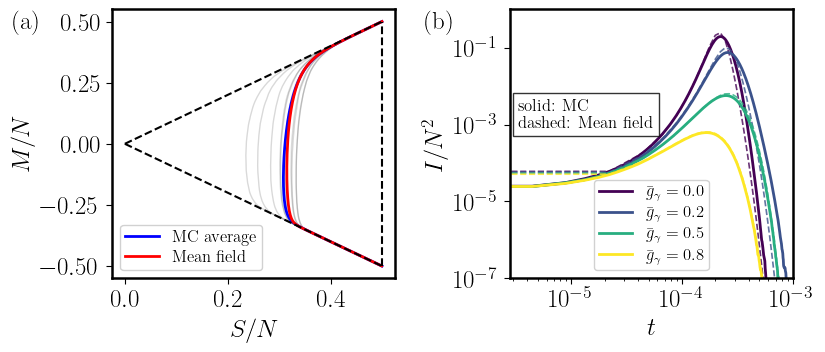

In [66]:
data = namedtuple_to_dict(load("../plot_data/fig_trajectories_gamma.jld2")["data"])
w, h = latex_plot_setup(ratio=0.9, scale=1.8)
fig, axes = subplots(ncols = 2, nrows = 1, figsize = (2 * w, h))
plot_fig2b_gamma!(axes[1], data)
data = load("../plot_data/fig_compare_mc_mf_intensity_gamma.jld2")
plot_compare_mc_mf_intensity_gamma!(axes[2], data)
ylim(bottom = 1e-7)
xlim(right = 1e-3)
tight_layout()

axes[1].text(-0.35, 1.0, "(a)", transform=axes[1].transAxes, va="top")
axes[2].text(-0.3, 1.0, "(b)", transform=axes[2].transAxes, va="top")
savefig("../data/fig4.pdf", bbox_inches = "tight")
